In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq, ifft
from funciones import procesar



In [2]:
# Cargamos el audio
fsa, señal_a = wavfile.read('tlfn-a.wav')

# Info básica de los datos
print(f"Sample Rate: {fsa} Hz")
print(f"Data Shape: {señal_a.shape}")

Sample Rate: 44100 Hz
Data Shape: (45000, 2)


In [3]:
# Parámetros de muestreo
Na  = len(señal_a)  # número de muestras en a
ta  = np.linspace(0, Na / fsa, Na, endpoint=False)  # eje de tiempo (sin repetir el extremo)

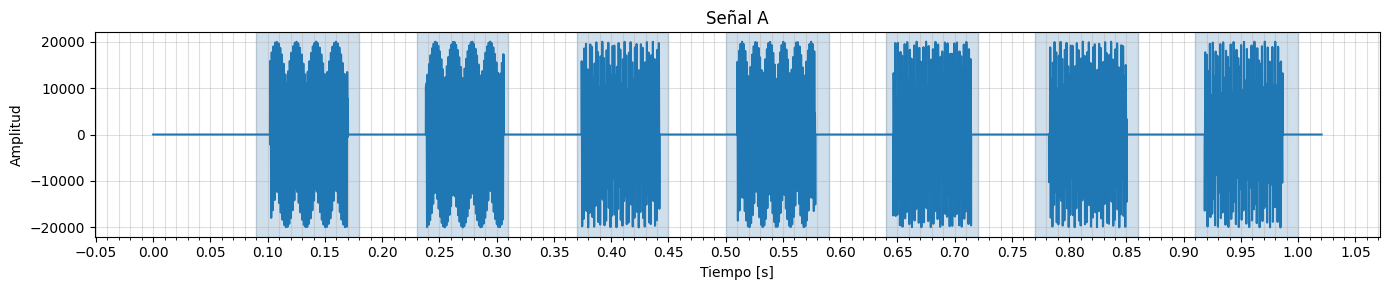

In [14]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(ta, señal_a[:, 0], zorder=2)
ax.set(xlabel="Tiempo [s]", ylabel="Amplitud", title="Señal A")
ax.xaxis.set_major_locator(plt.MultipleLocator(0.05))   # tick cada 50 ms
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.01))   # subtick cada 10 ms
ax.grid(True, which='both', alpha=0.4, zorder=1)

_cortes_a = [0.09, 0.18, 0.23, 0.31, 0.37, 0.45, 0.50, 0.59, 0.64, 0.72, 0.77, 0.86, 0.91, 1.00]
for k in range(0, len(_cortes_a), 2):
    ax.axvspan(_cortes_a[k], _cortes_a[k+1], alpha=0.25, color="steelblue", zorder=0)


plt.tight_layout()
plt.savefig(r'graficos\figura_1_señal_A_completa.png', dpi=120, bbox_inches='tight')
plt.show()

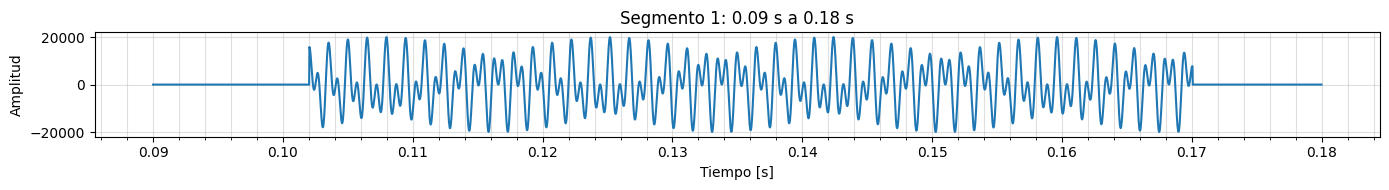

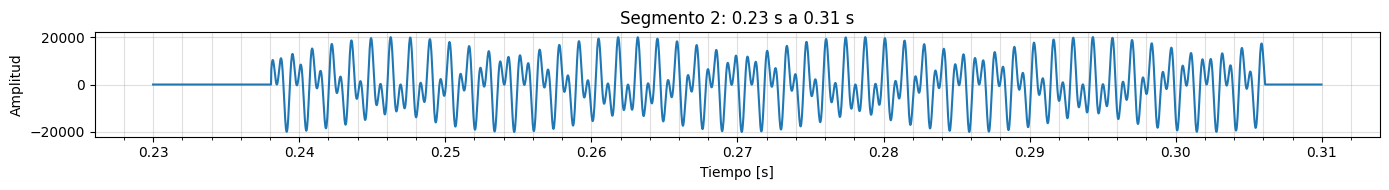

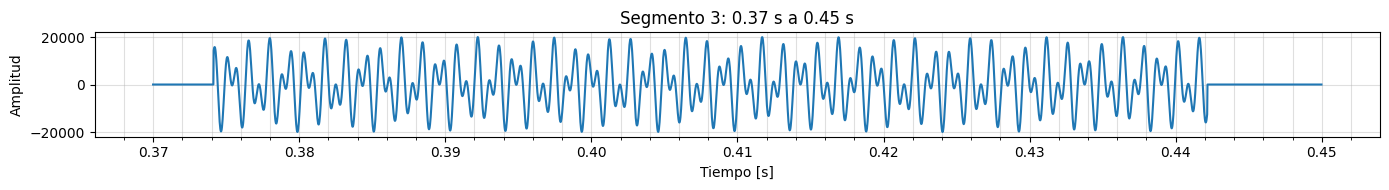

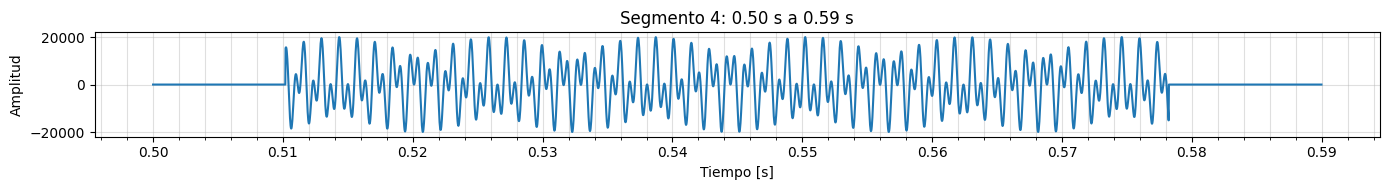

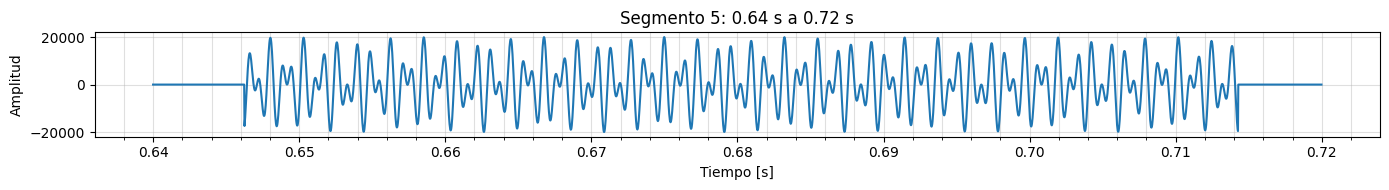

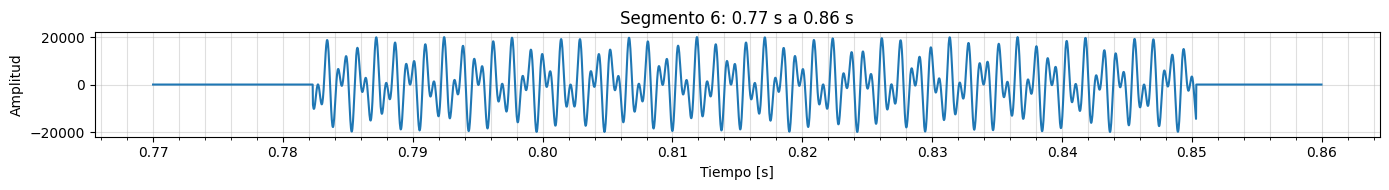

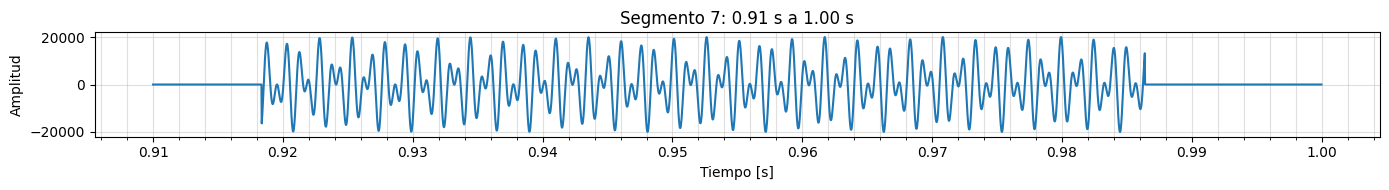

In [5]:
cortes = [0.09, 0.18, 0.23, 0.31, 0.37, 0.45, 0.50, 0.59, 0.64, 0.72, 0.77, 0.86, 0.91, 1.00]
lista_señales = []
#tomo de a pares los cortes para atrapar cada sonido entre cada par
for i in range(0, len(cortes), 2):
    inicio = cortes[i]
    fin = cortes[i+1]
    #print(f"Sonido entre {inicio:.2f} s y {fin:.2f} s")
    #partimos ta en esos intervalos
    mask = (ta >= inicio) & (ta < fin)
    segmento = señal_a[mask, 0]  # tomo solo el canal 0
    lista_señales.append(segmento)
    # graficar cada subseñal en su propio subplot
    fig, ax = plt.subplots(figsize=(14, 2))
    ax.plot(ta[mask], segmento)
    ax.set(xlabel="Tiempo [s]", ylabel="Amplitud", title=f"Segmento {i//2 + 1}: {inicio:.2f} s a {fin:.2f} s")
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.01))   # tick cada 10 ms
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.002))   # subtick cada 2 ms
    ax.grid(True, which='both', alpha=0.4)
    plt.tight_layout()
    plt.show()

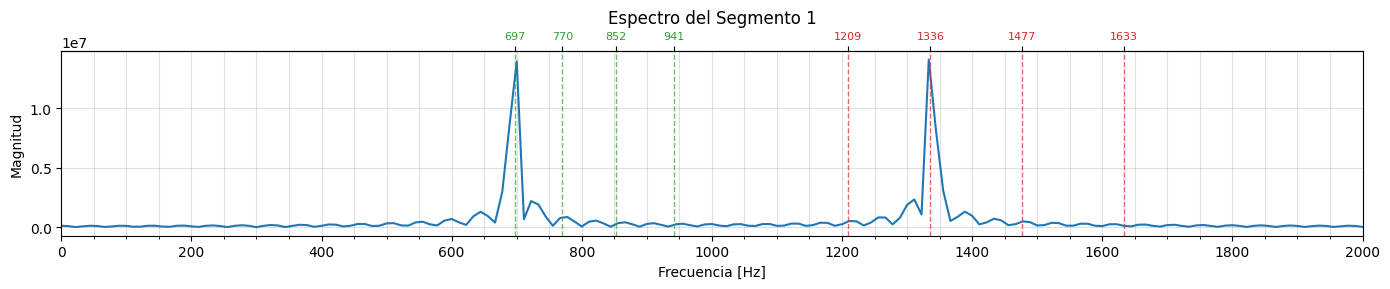

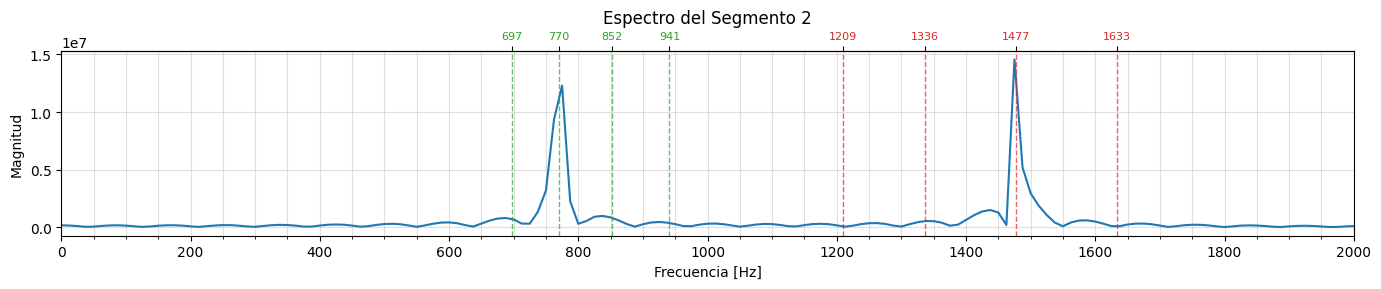

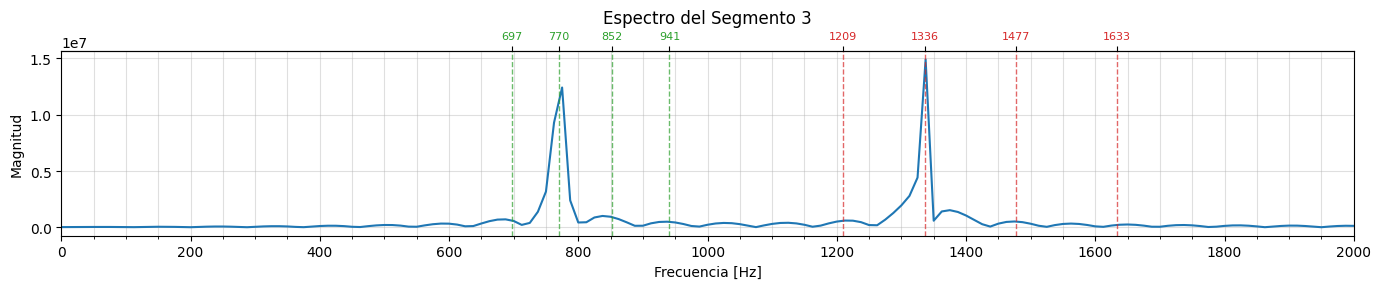

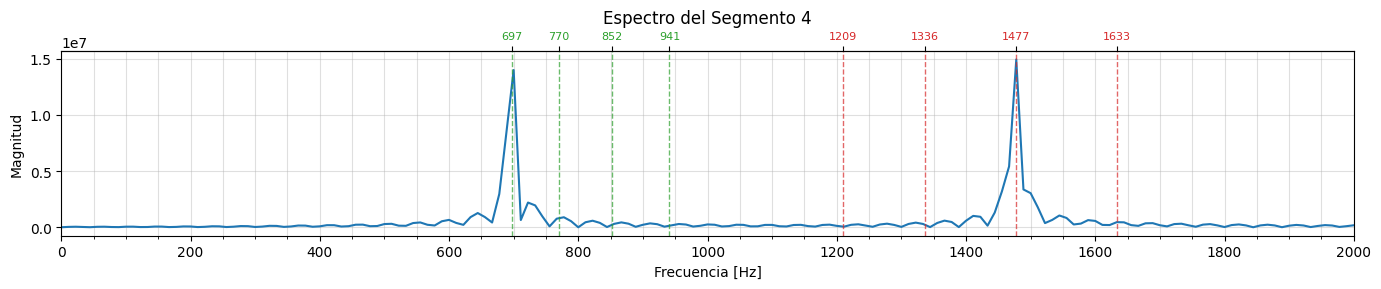

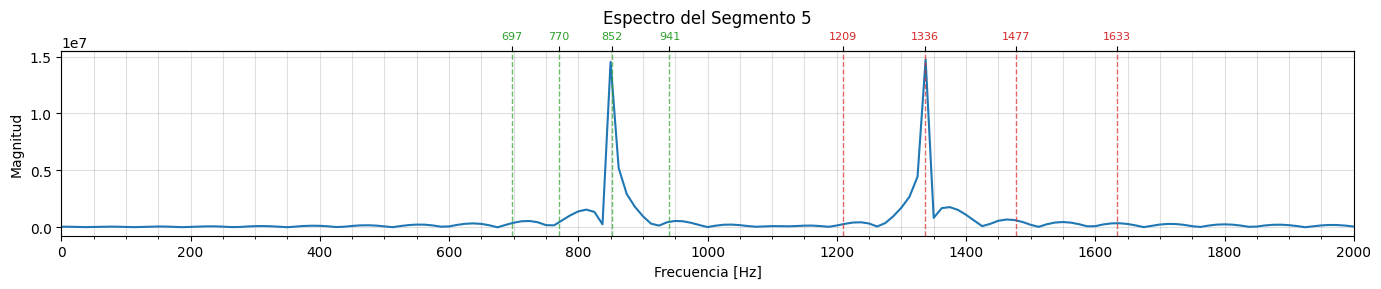

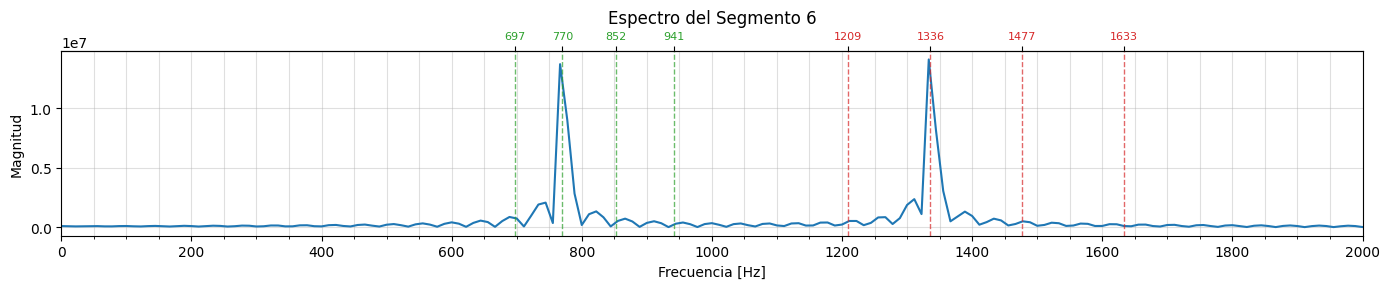

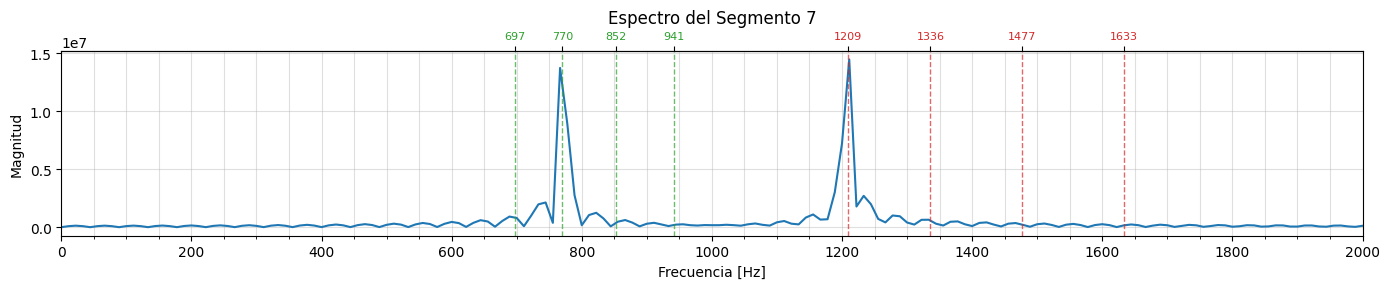

In [13]:
# Frecuencias DTMF estándar
frec_bajas_dtmf = [697, 770, 852, 941]
frec_altas_dtmf = [1209, 1336, 1477, 1633]
frec_dtmf = frec_bajas_dtmf + frec_altas_dtmf

# calculamos la FFT de cada subseñal y graficamos su espectro
for idx, segmento in enumerate(lista_señales):
    N = len(segmento)
    espectro = fft(segmento)
    frecuencias = fftfreq(N, d=1/fsa)
    
    # Graficar el espectro
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(frecuencias[:N//2], np.abs(espectro[:N//2]))  # solo la mitad positiva
    # Líneas verticales en las frecuencias DTMF
    for f in frec_bajas_dtmf:
        ax.axvline(f, color='tab:green', linestyle='--', alpha=0.7, linewidth=1)
    for f in frec_altas_dtmf:
        ax.axvline(f, color='tab:red', linestyle='--', alpha=0.7, linewidth=1)
    ax.set(xlabel="Frecuencia [Hz]", ylabel="Magnitud", title=f"Espectro del Segmento {idx + 1}")
    ax.set_xlim(0, 2000)  # limitar a 2000 Hz para mejor visualización
    ax.xaxis.set_major_locator(plt.MultipleLocator(200))   # tick cada 200 Hz
    ax.xaxis.set_minor_locator(plt.MultipleLocator(50))   # subtick cada 50 Hz
    ax.grid(True, which='both', alpha=0.4)
    # Eje x superior con las frecuencias DTMF etiquetadas
    ax_top = ax.secondary_xaxis('top')
    ax_top.set_xticks(frec_dtmf)
    ax_top.set_xticklabels([str(f) for f in frec_dtmf], fontsize=8)
    for label, f in zip(ax_top.get_xticklabels(), frec_dtmf):
        label.set_color('tab:green' if f in frec_bajas_dtmf else 'tab:red')
    plt.tight_layout()
    plt.savefig(f'graficos/figura_{idx+2}_segmento_{idx+1}.png', dpi=120, bbox_inches='tight')
    plt.show()

In [7]:
picos_a = procesar(lista_señales,   cortes,   fsa, 'A')

=== Señal A ===
Seg 1 [0.09-0.18 s]: f_baja = 700.0 Hz → 697 Hz  ·  f_alta = 1333.3 Hz → 1336 Hz  →  dígito 2
Seg 2 [0.23-0.31 s]: f_baja = 775.0 Hz → 770 Hz  ·  f_alta = 1475.0 Hz → 1477 Hz  →  dígito 6
Seg 3 [0.37-0.45 s]: f_baja = 775.0 Hz → 770 Hz  ·  f_alta = 1337.5 Hz → 1336 Hz  →  dígito 5
Seg 4 [0.50-0.59 s]: f_baja = 700.0 Hz → 697 Hz  ·  f_alta = 1477.8 Hz → 1477 Hz  →  dígito 3
Seg 5 [0.64-0.72 s]: f_baja = 850.0 Hz → 852 Hz  ·  f_alta = 1337.5 Hz → 1336 Hz  →  dígito 8
Seg 6 [0.77-0.86 s]: f_baja = 766.7 Hz → 770 Hz  ·  f_alta = 1333.3 Hz → 1336 Hz  →  dígito 5
Seg 7 [0.91-1.00 s]: f_baja = 766.7 Hz → 770 Hz  ·  f_alta = 1211.1 Hz → 1209 Hz  →  dígito 4
Número A: 2653854

